# Runge-Kutta method 
Solve: $$Y' = F(t, Y)$$ for $t \in \mathbb{R}$ and $Y \in \mathbb{R}^n$. The iterative method is the following

$$
\begin{aligned}
k_{1}&=\ f(t_{n},y_{n}),\\
k_{2}&=\ f\left(t_{n}+{\frac {h}{2}},y_{n}+k_{1}{\frac {h}{2}}\right)\\
k_{3}&=\ f\!\left(t_{n}+{\frac {h}{2}},y_{n}+k_{2}{\frac {h}{2}}\right)\\
k_{4}&=\ f\!\left(t_{n}+h,y_{n}+hk_{3}\right)\\
y_{n+1}&=y_{n}+{\frac {h}{6}}\left(k_{1}+2k_{2}+2k_{3}+k_{4}\right)\\
\end{aligned}
$$

In [11]:
import numpy as np
from typing import Callable


def runge_kutta_4(
        f: Callable,
        initialcond: np.ndarray | float | int,
        tt: np.ndarray, # it better be a np.linspace
) -> np.ndarray:
    n, = tt.shape
    h = tt[1] - tt[0]  # it better be a np.linspace
    try:
        dim, = initialcond.shape
        udim = (n, dim)
    except AttributeError:
        udim = (n, )
    uu = np.empty(udim, np.float64)
    uu[0] = initialcond
    for i in range(n - 1):
        k1 = f(tt[i]      , uu[i])
        k2 = f(tt[i] + h/2, uu[i] + k1*h/2)
        k3 = f(tt[i] + h/2, uu[i] + k2*h/2)
        k4 = f(tt[i] + h  , uu[i] + k3*h)
        uu[i + 1] = uu[i] + (h / 6)*(k1 + 2*k2 + 2*k3 + k4)
    return uu

## Example
Consider $y' = \sin^2(t) \cdot y$, with initial condition $y(0) = 1$.

In [12]:
def f(t, y) -> np.float64:
    return np.sin(t) ** 2 * y

tt = np.linspace(0, 5, 50)
y0 = 1
uu = runge_kutta_4(f, y0, tt)

The exact solution to this problem is $$y = \exp\left(\dfrac{t}{2} - \dfrac{1}{4} \sin(2\,t)\right)$$

In [13]:
def solution(t):
    exponent = .5 * t - .25 * np.sin(2 *t)
    return np.exp(exponent)

label = r'$\exp\left(\dfrac{t}{2}-\dfrac{1}{4}\sin(2t)\right)$'

Plotting the result against the exact solution

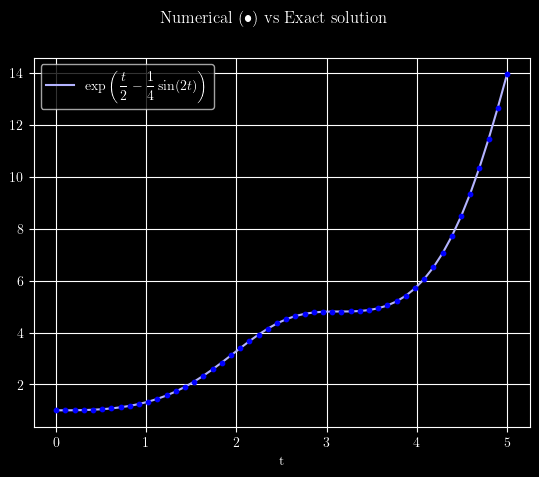

In [14]:
import matplotlib.pyplot as plt

from utils.visualization import compare_numerical, init

init()

fig, ax = compare_numerical(
    solution, [0, 5], tt, uu,
    labels=label, colors='blue'
)

plt.show()


## Higher dimensional example
Consider the non-linear system of equations 
$$
\begin{align*}
y'(t) &= \exp(z(t)) + 1 \\
z'(t) &= y(t) - t \\
y(0) &= 0 \\
z(0) &= 0
\end{align*}
$$

Transforming the system in our terms, we have
$$
\begin{align*}
F(t, Y) &= (\exp(Y_2) + 1, Y_1 - t) \\
Y(0) &= (0, 0)
\end{align*}
$$

In [15]:
def bigf(
        t: float,
        y: np.ndarray
) -> np.ndarray:
    return np.array([np.exp(y[1]) + 1, y[0] - t])

y0 = np.zeros((2, ))
ttF = np.linspace(0, 2, 50)

Apply Runge Kutta

In [16]:
uuF = runge_kutta_4(bigf, y0, ttF)

The exact solution of the system being solved is:
$$
\left(t+\sqrt{2} \tan\left(\frac{t}{\sqrt{2}}\right),\, \log\left(1+\tan^2\left(\frac{t}{\sqrt{2}}\right)\right)\right)
$$

In [17]:
def F_solution(
        t: float
) -> np.ndarray:
    tsqrt = t / np.sqrt(2)
    first = t + np.sqrt(2) * np.tan(tsqrt)
    second = np.log(1 + np.tan(tsqrt) ** 2)
    return np.array((first, second))


labels = [
    r"$t+\sqrt{2} \tan\left(\frac{t}{\sqrt{2}}\right)$",
    r"$\log\left(1+\tan^2\left(\frac{t}{\sqrt{2}}\right)\right)$"
]

Plotting the numerical result against its exact solution

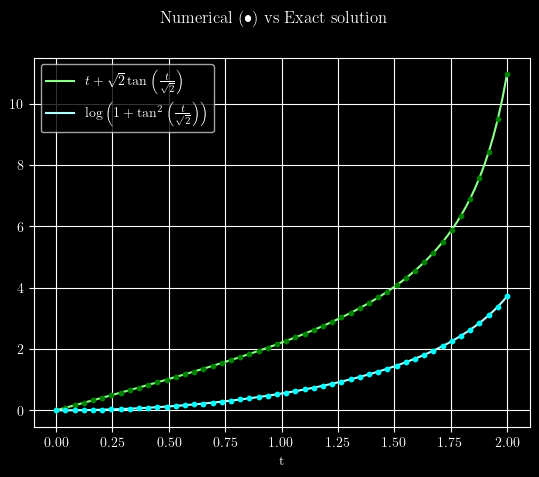

In [18]:
fig, ax = compare_numerical(
    F_solution, [0, 2, 100], ttF, uuF.T,
    labels=labels, colors=['green', 'cyan']
)

plt.show()